In [1]:
# Imports de base pour tous les exercices
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, KBinsDiscretizer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA


SEED = 42

# 1. Préparation des données
## 1.1 Récupération des données

In [2]:
df_orig = pd.read_csv("data/export.csv", sep=";")
df = df_orig.copy()

print("Original data shape", df_orig.shape)
df["CONTENTS"] = "X"

# suppression des users pour lesquelles il y a moins de 50% de variables
#threshold = df.shape[1] * 0.5
#df = df.dropna(axis=0, thresh=threshold)
#print("Size", df.shape)

# suppression des variables pour lesquelles il y a moins de 50% de users
threshold = df.shape[0] * 0.4
df = df.dropna(axis=1, thresh=threshold)
print("Final size", df.shape)

Original data shape (31991, 479)
Final size (31991, 439)


/var/folders/wv/l5b9d65d6170hn122_d3qcvw0000gp/T/ipykernel_95925/1301694532.py:1: DtypeWarning: Columns (0: MOTIVATION_VALUE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orig = pd.read_csv("data/export.csv", sep=";")


## 1.2 Division des colonnes par type

In [3]:
CAT_COLS = list()
BIN_COLS = list()
NUM_COLS = list()
for idx, c in enumerate(df.columns):
    if c == "CONTENTS":
        break

    #if c.startswith("MOTIVATION_"):
    #    continue

    if c == "user id":# or c.endswith("_AGREE") or c == "MOTIVATION_VALUE":
        continue

    if df[c].dtype == "str":
        CAT_COLS.append(c)
        continue

    if df[c].dtype in ["float64", "int"] and len(df[c].value_counts()) == 2:
        BIN_COLS.append(c)
        continue

    NUM_COLS.append(c)

print(f"Colonnes numériques: {len(NUM_COLS)}", NUM_COLS)
print(f"Colonnes discrètes: {len(BIN_COLS)}", BIN_COLS)
print(f"Colonnes catégorielles: {len(CAT_COLS)}", CAT_COLS)

Colonnes numériques: 1 ['USER_AGE']
Colonnes discrètes: 8 ['MP_EVITEMENT_SOCRATE', 'MP_PROCEDURE_SOCRATE', 'MP_OPTION_SOCRATE', 'MP_ALLER_VERS_SOCRATE', 'USER_OWNS_MASK', 'USER_OWNS_SUBSCRIPTION', 'USER_USE_ANDROID', 'USER_USE_IOS']
Colonnes catégorielles: 2 ['USER_GENDER', 'USER_APP_LANGUAGE']


## 1.3 Suppression des outliners dans les donnée numériques

In [4]:
imputer = SimpleImputer(strategy="median") # TODO: try mean
df_median = df.copy()
df_median[NUM_COLS] = imputer.fit_transform(df_median[NUM_COLS])
z_scores = stats.zscore(df_median[NUM_COLS])
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)

df_z_filtered = df_median[filtered_entries]

outlier_indices_z = df_median.index[~filtered_entries].tolist()
print(f"Outliers détectés par Z-Score: {(~filtered_entries).sum()} observations")
print(f"Index des outliers (Z-Score): {outlier_indices_z}")
print(f"Nouvelles dimensions: {df_z_filtered.shape}")
print(f"Anciennes dimensions: {df.shape}")

df = df_z_filtered

Outliers détectés par Z-Score: 421 observations
Index des outliers (Z-Score): [2, 8, 157, 338, 364, 446, 470, 495, 682, 724, 890, 975, 1011, 1183, 1258, 1405, 1556, 1743, 1747, 1755, 1814, 1839, 1894, 1921, 1923, 1929, 1950, 1961, 2234, 2311, 2472, 2530, 2545, 2685, 2710, 2789, 2847, 2894, 3127, 3189, 3218, 3470, 3590, 3596, 3676, 3794, 3801, 3881, 3910, 3964, 3993, 4034, 4200, 4302, 4429, 4536, 4561, 4649, 4655, 4665, 4765, 4814, 4818, 4888, 5044, 5055, 5102, 5119, 5207, 5220, 5360, 5488, 5520, 5552, 5677, 5700, 6030, 6053, 6084, 6172, 6229, 6467, 6474, 6779, 6790, 6884, 6893, 6987, 7108, 7136, 7175, 7261, 7337, 7381, 7535, 7547, 7579, 7617, 7686, 7832, 7857, 7913, 8028, 8042, 8065, 8330, 8331, 8398, 8407, 8409, 8431, 8438, 8525, 8526, 8547, 8722, 8779, 8793, 8807, 8949, 8981, 9054, 9095, 9138, 9167, 9258, 9277, 9429, 9534, 9543, 9610, 9620, 9902, 9916, 9954, 10072, 10121, 10185, 10274, 10344, 10874, 10981, 11139, 11291, 11303, 11369, 11398, 11424, 11621, 11661, 11786, 11903, 11984, 1

## 1.4 Plot PCA

## 1.5 Distribution des valeurs numériques

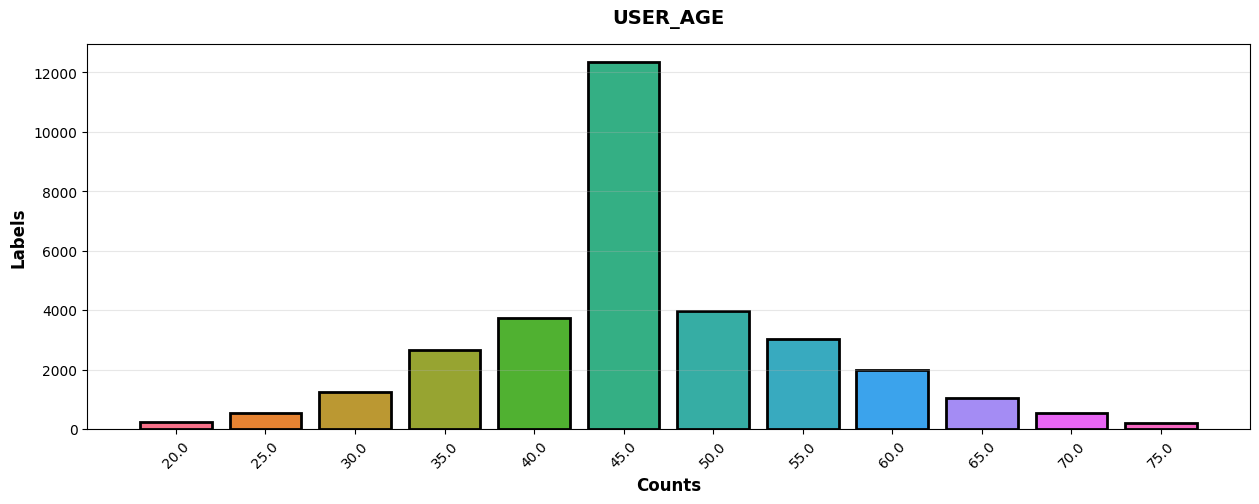

In [5]:
for idx, col in enumerate(NUM_COLS):
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    values = df[col].value_counts(sort=False).sort_index()
    colors = sns.color_palette("husl", len(values))
    bars = ax.bar(range(len(values)), values.values, color=colors, edgecolor='black', linewidth=2)
    ax.set_xlabel('Counts', fontsize=12, fontweight='bold')
    ax.set_ylabel('Labels', fontsize=12, fontweight='bold')
    ax.set_title(col, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(values.index)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)


## 1.6 Nettoyage des prédictions

In [6]:
content_vals = dict()
for idx, col in enumerate(df.loc[:,"CONTENTS":]):
    if idx == 0:
        continue

    if df[col].nunique() == 1:
        continue

    tmp = (df[col] != 0).astype(int)
    val = tmp.value_counts()[0]/(tmp.value_counts()[0]+tmp.value_counts()[1])
    content_vals[col] = val

content_vals = {k: v for k, v in sorted(content_vals.items(), key=lambda item: item[1]) if 0.25 <= v <= 0.75}
for k, v in content_vals.items():
    print(k, v)

Qui êtes-vous? 0.25292999683243583
Bien dormir 0.40395945517896736
Relaxation 0.48751979727589484
Qu'est-ce que je veux? 0.5060500475134622
Apaiser les pensées 0.5843522331327209
Comprendre l’origine du stress 0.6790307253721888
Mon Cogito 0.6859360152043079
Stop grignotage 0.690180551156161
Douce nuit 0.7020905923344948
Bon voyage ! 0.7072853975293
Phenix Santé 0.7174532784288882
Qui dort, dîne? 0.7205574912891987
Mincir 0.7267659170098194
Mes déclencheurs 0.7399113082039911
Liste des déclencheurs 0.7431105479885968
Nettoyer son esprit 0.7493189737092176


## 1.7 Jeu de données final

In [7]:
X = df[NUM_COLS + CAT_COLS + BIN_COLS]
print(f"Data shape: {X.shape}")
X.describe()

Data shape: (31570, 11)


,USER_AGE,MP_EVITEMENT_SOCRATE,MP_PROCEDURE_SOCRATE,MP_OPTION_SOCRATE,MP_ALLER_VERS_SOCRATE,USER_OWNS_MASK,USER_OWNS_SUBSCRIPTION,USER_USE_ANDROID,USER_USE_IOS
count,31570.000000,13203.000000,13201.000000,13202.000000,13200.000000,31570.000000,31570.000000,31570.000000,31570.000000
mean,46.261482,0.619556,0.156882,0.842827,0.380227,0.684701,0.452360,0.594710,0.455242
std,9.355242,0.485514,0.363703,0.363978,0.485461,0.464642,0.497733,0.490956,0.498001
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,45.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,50.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,75.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


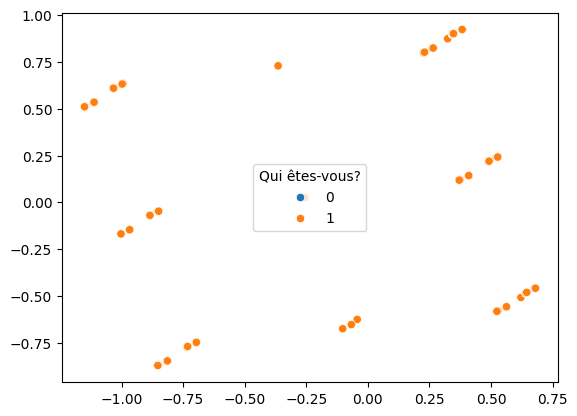

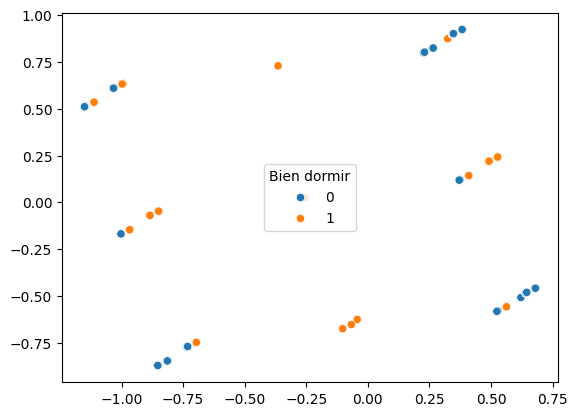

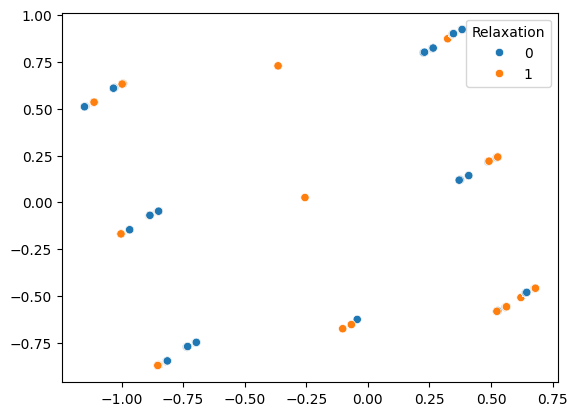

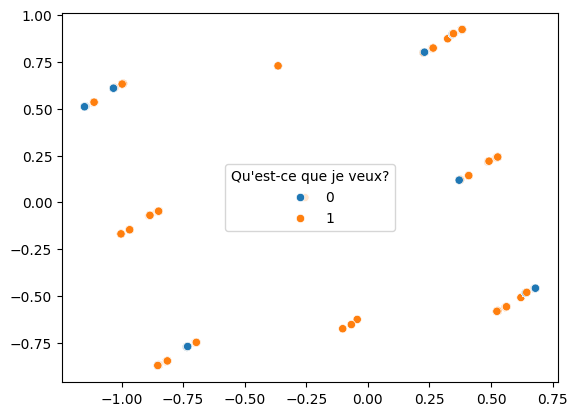

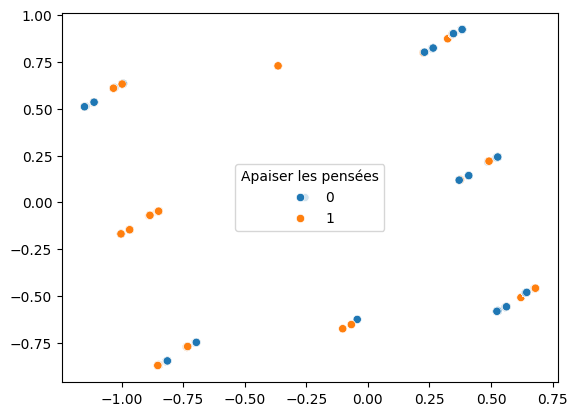

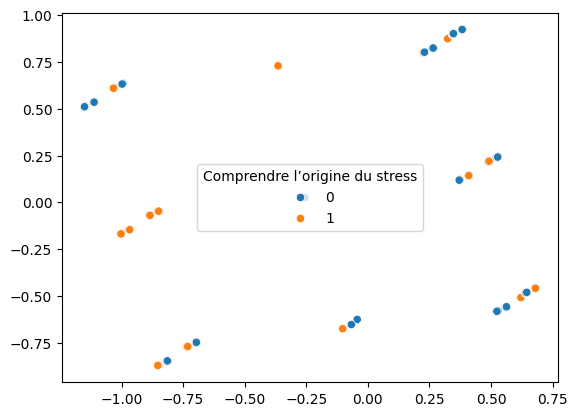

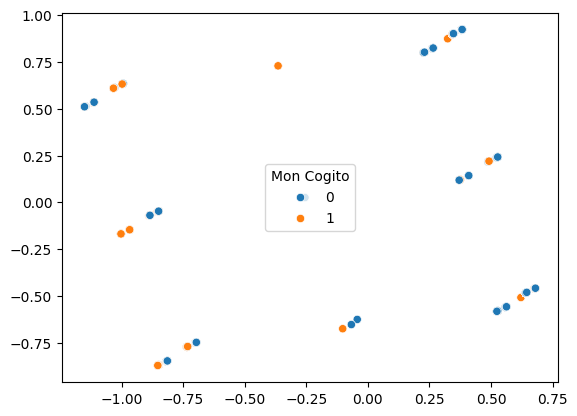

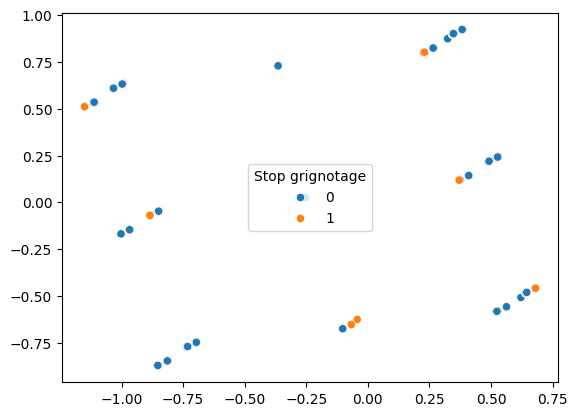

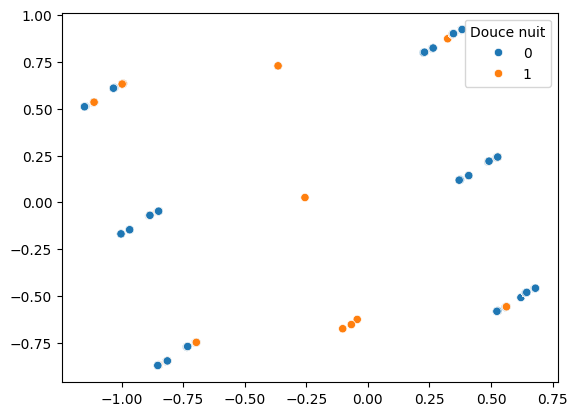

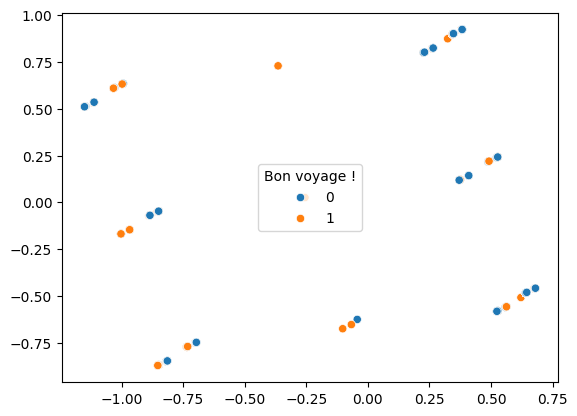

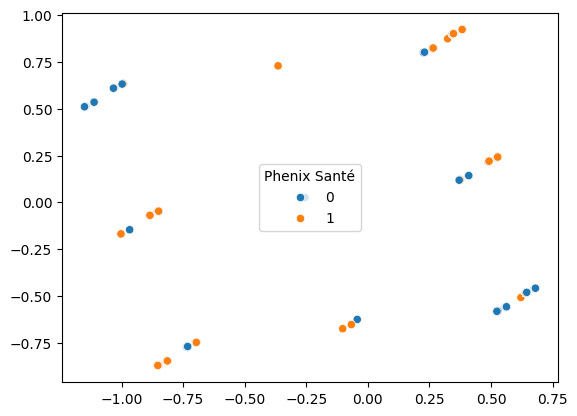

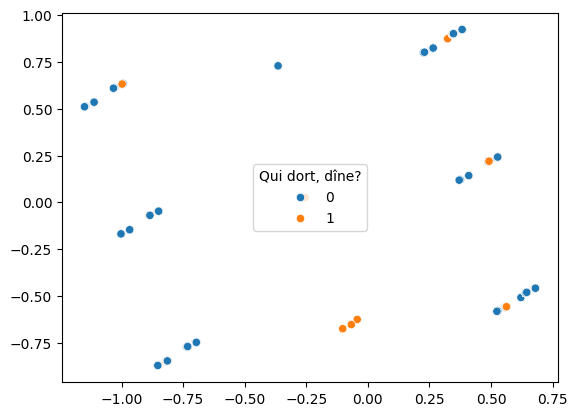

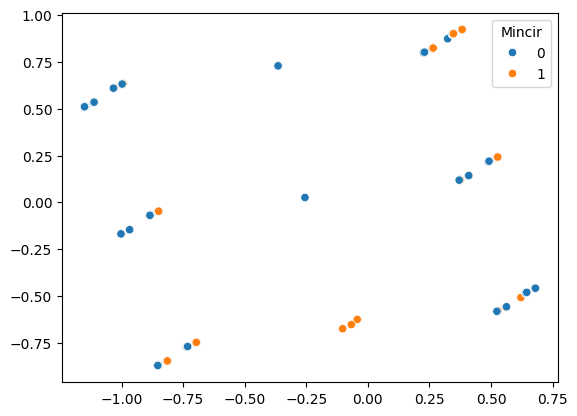

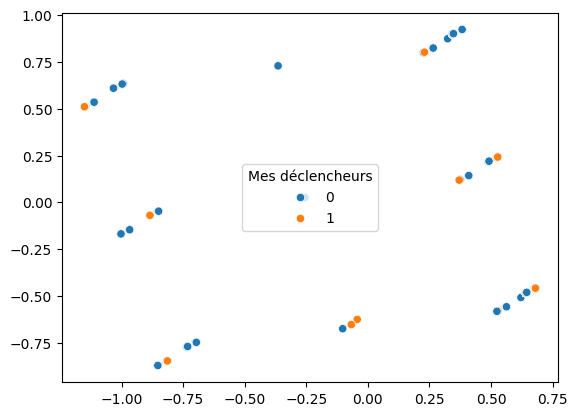

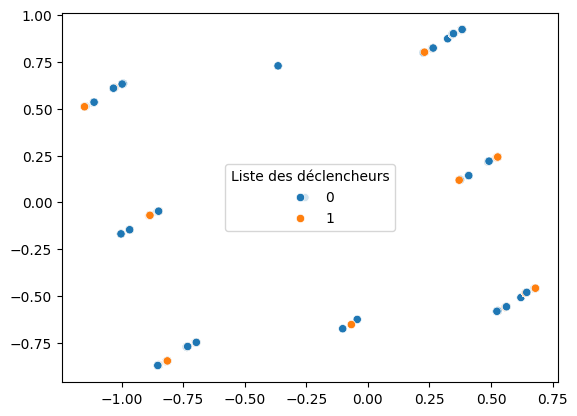

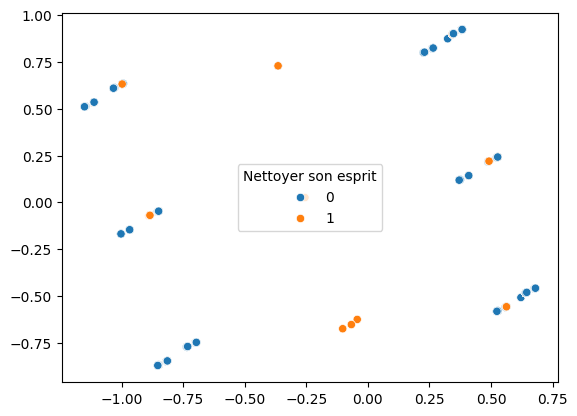

In [8]:
df_scatter = df.select_dtypes(include='number').dropna()
X_scatter = df_scatter[BIN_COLS]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scatter)

for idx, k in enumerate(content_vals.keys()):
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_scatter[k])
    plt.show()
    #if idx == 4:
    #    break

# 2. Recherche du meilleur estimator
## 2.1 Préparation du pipeline

In [9]:
def encode_lang(x):
    return (x == "fr").astype(int)

def encode_gender(x):
    return (x == "WOM").astype(int)

In [10]:
numeric_preprocess = Pipeline([
    ("imputer", KNNImputer()),#SimpleImputer(strategy="median")
    ("scaler", StandardScaler()),
    #("discretizer", KBinsDiscretizer(n_bins=5, encode='ordinal', quantile_method='averaged_inverted_cdf'),),
    #("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

cat_preprocess = Pipeline([
    ("imputer", KNNImputer()),#SimpleImputer(strategy="most_frequent")
])

lang_preprocess = Pipeline([
    ("encode", FunctionTransformer(encode_lang)),
    ("imputer", KNNImputer()),#SimpleImputer(strategy="most_frequent")
])

gender_preprocess = Pipeline([
    ("encode", FunctionTransformer(encode_gender)),
    ("imputer", KNNImputer()),#SimpleImputer(strategy="most_frequent")
])

preprocess = ColumnTransformer([
    ("lang", lang_preprocess, ["USER_APP_LANGUAGE"]),
    ("gender", lang_preprocess, ["USER_GENDER"]),
    ("num", numeric_preprocess, NUM_COLS),
    ("cat", cat_preprocess, BIN_COLS),
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", None)
])


## 2.2 Grid search

In [11]:
PARAM_GRIDS = {
    "Random Forest": {
        "model": [RandomForestClassifier(random_state=SEED)],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [1, 2, 3, 5, 10],
        #"preprocess__num__imputer": [SimpleImputer(strategy="median"), KNNImputer()],
        #"preprocess__cat__imputer": [SimpleImputer(strategy="most_frequent"), KNNImputer()],
    },
    "Logistic Regression": {
        "model": [LogisticRegression(max_iter=2000, random_state=SEED)],
        "model__C": [0.01, 0.1, 1, 10],
        #"preprocess__num__imputer": [SimpleImputer(strategy="median"), KNNImputer()],
        #"preprocess__cat__imputer": [SimpleImputer(strategy="most_frequent"), KNNImputer()],
    },
    "SVM": {
        'model': [SVC(random_state=SEED, probability=True)],
        'model__kernel': ['rbf', 'linear'],
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 0.01, 0.1, 1],
        #"preprocess__num__imputer": [SimpleImputer(strategy="median"), KNNImputer()],
        #"preprocess__cat__imputer": [SimpleImputer(strategy="most_frequent"), KNNImputer()],
    },
    "KNN": {
        "model": [KNeighborsClassifier()],
        "model__n_neighbors": [3, 4, 5, 6, 7],   
        #"preprocess__num__imputer": [SimpleImputer(strategy="median"), KNNImputer()],
        #"preprocess__cat__imputer": [SimpleImputer(strategy="most_frequent"), KNNImputer()],
    },
    "Gradient Boosting": {
        "model": [GradientBoostingClassifier(random_state=SEED)],
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5],
        #"preprocess__num__imputer": [SimpleImputer(strategy="median"), KNNImputer()],
        #"preprocess__cat__imputer": [SimpleImputer(strategy="most_frequent"), KNNImputer()],
    }
}

In [12]:
DATASETS = dict()

for col, v in content_vals.items():
    _y = (df[col] != 0).astype(int)

    X_train_raw, _X_test, y_train_raw, _y_test = train_test_split(
        X, _y,
        test_size=0.2,
        stratify=_y,
        random_state=SEED
    )

    _X_train, _X_val, _y_train, _y_val = train_test_split(
        X_train_raw, y_train_raw,
        test_size=0.25,
        stratify=y_train_raw,
        random_state=SEED
    )

    DATASETS[col] = {
        "X_train": _X_train,
        "y_train": _y_train,
        "X_test": _X_test,
        "y_test": _y_test,
        "X_val": _X_val,
        "y_val": _y_val
    }

In [13]:
def get_best_estimator(col, estimator_type):

    dataset = DATASETS[col]
    param_grid = PARAM_GRIDS[estimator_type]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    grid_cv = GridSearchCV(    
        pipeline,    
        param_grid=param_grid,     
        cv=cv,
        scoring="roc_auc",
        n_jobs=1
    )

    grid_cv.fit(dataset["X_val"], dataset["y_val"])

    return grid_cv

best_params_for_content = dict()
for col in content_vals.keys():
    print(col)
    best_score = 0.0
    best_g = None
    for estimator in PARAM_GRIDS.keys():
        g = get_best_estimator(col, estimator)

        print("\t", estimator, g.best_score_)
        if g.best_score_ > best_score:
            best_score = g.best_score_
            best_g = g

    #if best_g.best_score_ > 0.75:
    best_params_for_content[col] = best_g
    print("BEST", best_g.best_score_, best_g.best_params_)
    #else:
    #    print("BEST but not enough", best_g.best_score_, best_g.best_params_)


Qui êtes-vous?
	 Random Forest 0.9778850345968829
	 Logistic Regression 0.8411899630768254
	 SVM 0.9694012096604936
	 KNN 0.9739081671571201
	 Gradient Boosting 0.9776562283516815
BEST 0.9778850345968829 {'model': RandomForestClassifier(random_state=42), 'model__max_depth': 10, 'model__n_estimators': 300}
Bien dormir
	 Random Forest 0.642191860347857
	 Logistic Regression 0.6086696176021447
	 SVM 0.633586548302546
	 KNN 0.6134585977309582
	 Gradient Boosting 0.6435217526255562
BEST 0.6435217526255562 {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}
Relaxation
	 Random Forest 0.7995303765061622
	 Logistic Regression 0.738571110698859
	 SVM 0.7821808981837548
	 KNN 0.7680794977970812
	 Gradient Boosting 0.7987836148983177
BEST 0.7995303765061622 {'model': RandomForestClassifier(random_state=42), 'model__max_depth': 5, 'model__n_estimators': 100}
Qu'est-ce que je veux?
	 Random Forest 0.9214307609316709

Qui êtes-vous? {'model': RandomForestClassifier(random_state=42), 'model__max_depth': 10, 'model__n_estimators': 300}
Entrainement fini
Importance des features
('USER_APP_LANGUAGE', np.float64(0.5575604249299615))
('USER_OWNS_MASK', np.float64(0.17595977303528532))
('MP_OPTION_SOCRATE', np.float64(0.08100499308266068))
('USER_OWNS_SUBSCRIPTION', np.float64(0.062109350341114394))
('MP_ALLER_VERS_SOCRATE', np.float64(0.04776787735129896))
('MP_EVITEMENT_SOCRATE', np.float64(0.046175858312496966))
('MP_PROCEDURE_SOCRATE', np.float64(0.020723504432845298))
('USER_USE_ANDROID', np.float64(0.0044642102810104126))
('USER_USE_IOS', np.float64(0.00247068086202211))
('USER_AGE', np.float64(0.00176332737130425))
('USER_GENDER', np.float64(0.0))
Validation
Score:  0.9326892619575546
Accuracy: 0.9326892619575546
ROC AUC: 0.9747493345655922
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      1597
           1       1.00      0.91      0.95      471

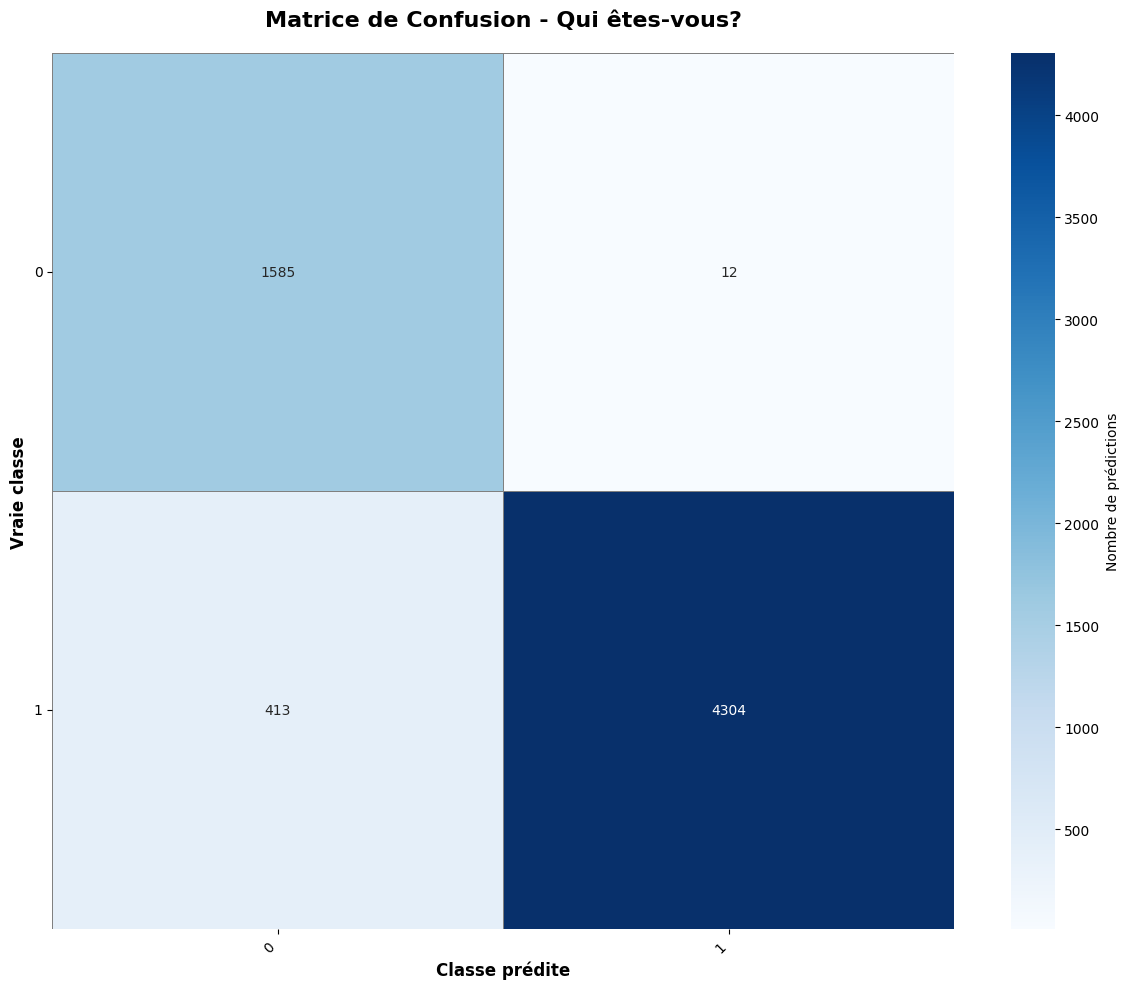

Bien dormir {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}
Entrainement fini
Validation
Score:  0.6629711751662971
Accuracy: 0.6629711751662971
ROC AUC: 0.6725406022222401
              precision    recall  f1-score   support

           0       0.60      0.48      0.54      2551
           1       0.69      0.78      0.73      3763

    accuracy                           0.66      6314
   macro avg       0.65      0.63      0.64      6314
weighted avg       0.66      0.66      0.66      6314



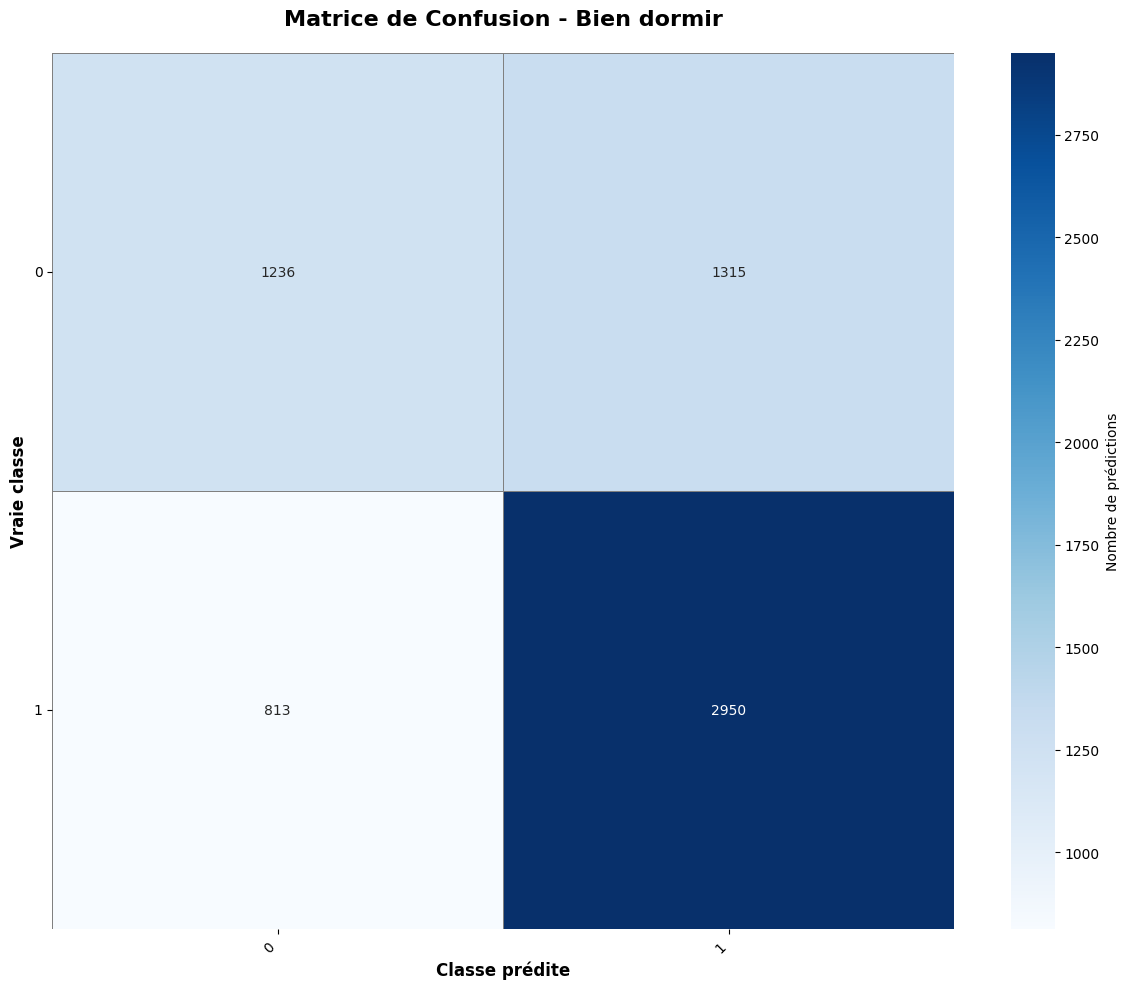

Relaxation {'model': RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42), 'model__max_depth': 5, 'model__n_estimators': 100}
Entrainement fini
Importance des features
('USER_OWNS_MASK', np.float64(0.4154767978016994))
('MP_EVITEMENT_SOCRATE', np.float64(0.15040851454468757))
('MP_ALLER_VERS_SOCRATE', np.float64(0.13596435528561857))
('USER_OWNS_SUBSCRIPTION', np.float64(0.12178859036940909))
('USER_APP_LANGUAGE', np.float64(0.07157009833621972))
('MP_PROCEDURE_SOCRATE', np.float64(0.06271513161479819))
('MP_OPTION_SOCRATE', np.float64(0.03453505973338159))
('USER_USE_IOS', np.float64(0.003521157310000042))
('USER_USE_ANDROID', np.float64(0.0031210711435126102))
('USER_AGE', np.float64(0.0008992238606731613))
('USER_GENDER', np.float64(0.0))
Validation
Score:  0.7348748812163446
Accuracy: 0.7348748812163446
ROC AUC: 0.8078181636736167
              precision    recall  f1-score   support

           0       0.75      0.69      0.72      3078
           1       0.72  

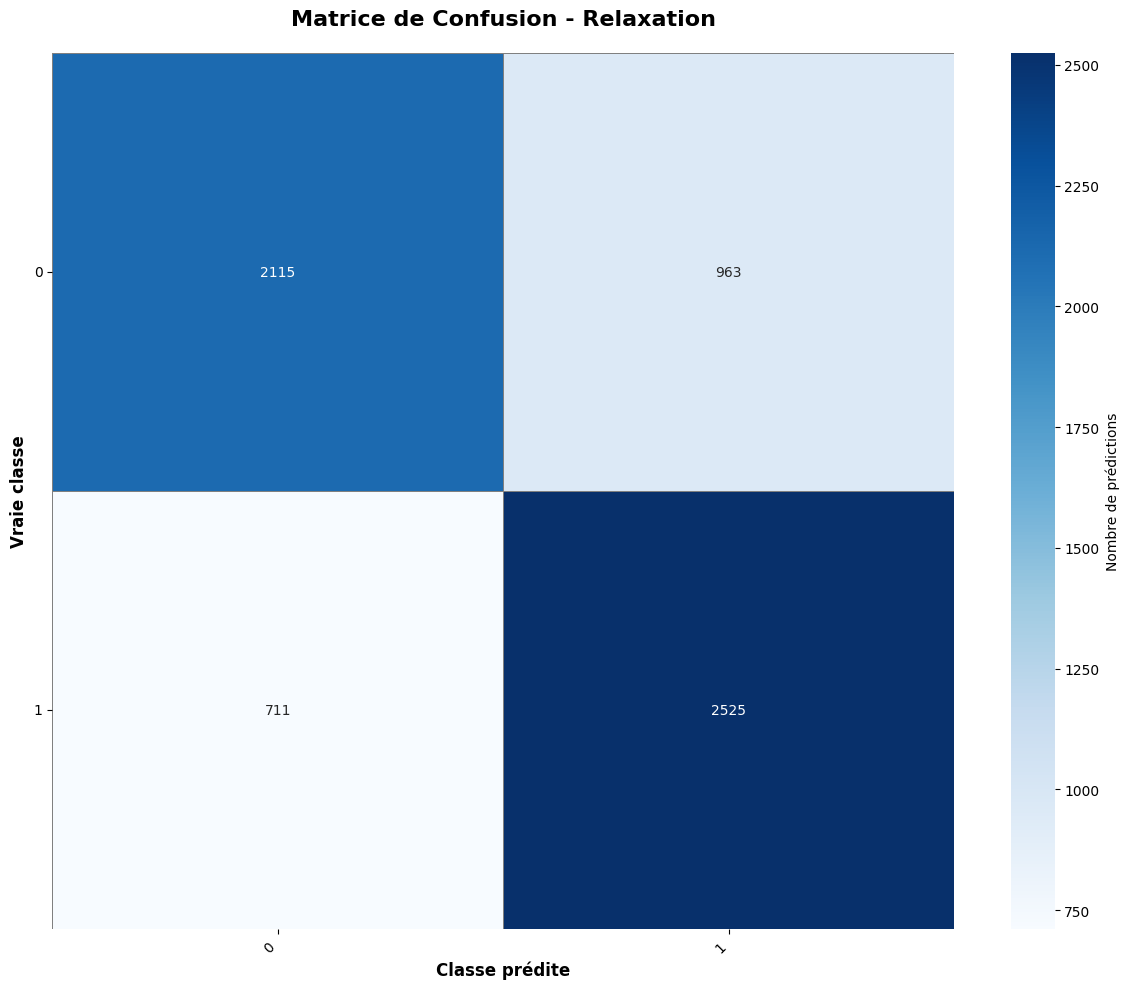

Qu'est-ce que je veux? {'model': GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200,
                           random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.8414634146341463
Accuracy: 0.8414634146341463
ROC AUC: 0.9126238245976876
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      3195
           1       0.82      0.87      0.84      3119

    accuracy                           0.84      6314
   macro avg       0.84      0.84      0.84      6314
weighted avg       0.84      0.84      0.84      6314



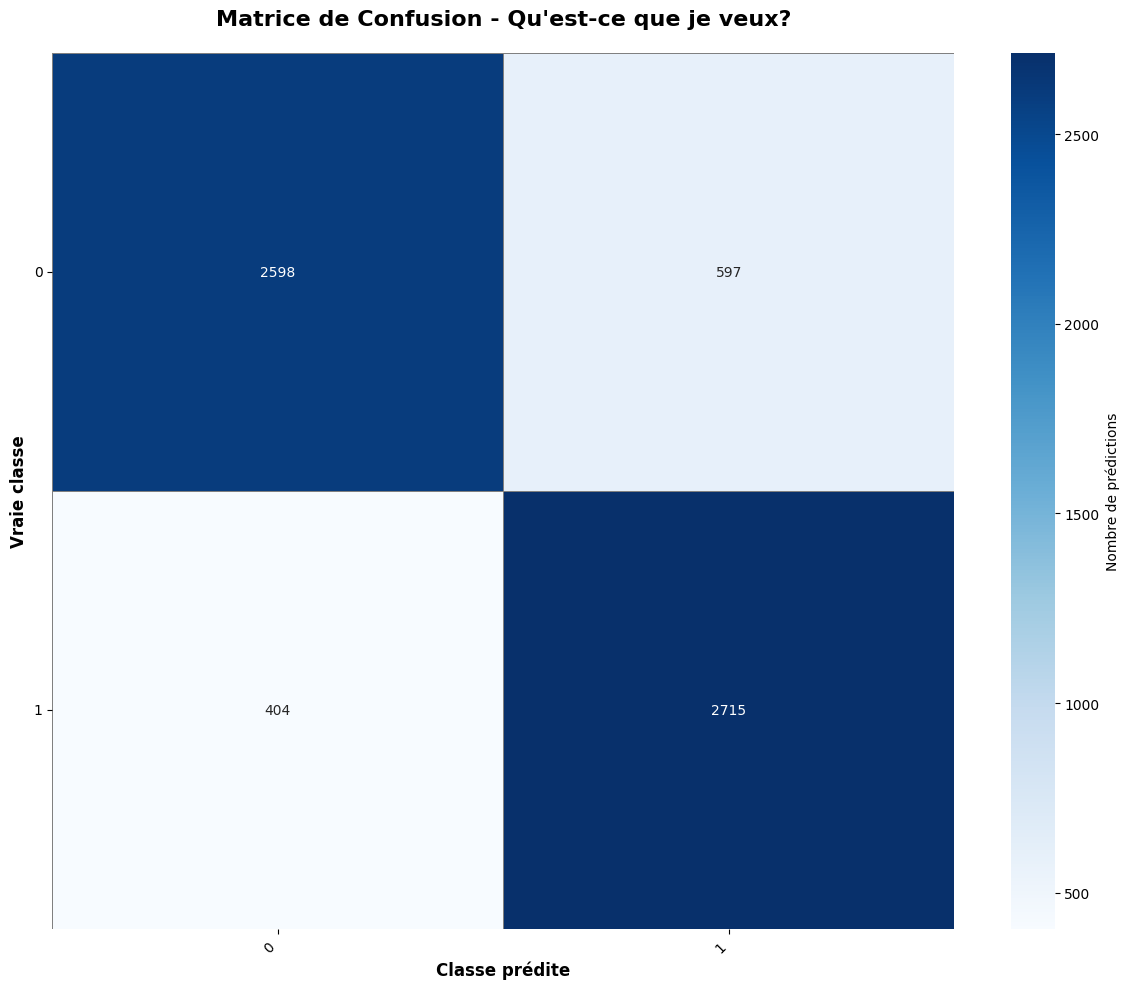

Apaiser les pensées {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.6838770985112449
Accuracy: 0.6838770985112449
ROC AUC: 0.7150250553572609
              precision    recall  f1-score   support

           0       0.73      0.72      0.73      3690
           1       0.62      0.64      0.63      2624

    accuracy                           0.68      6314
   macro avg       0.68      0.68      0.68      6314
weighted avg       0.69      0.68      0.68      6314



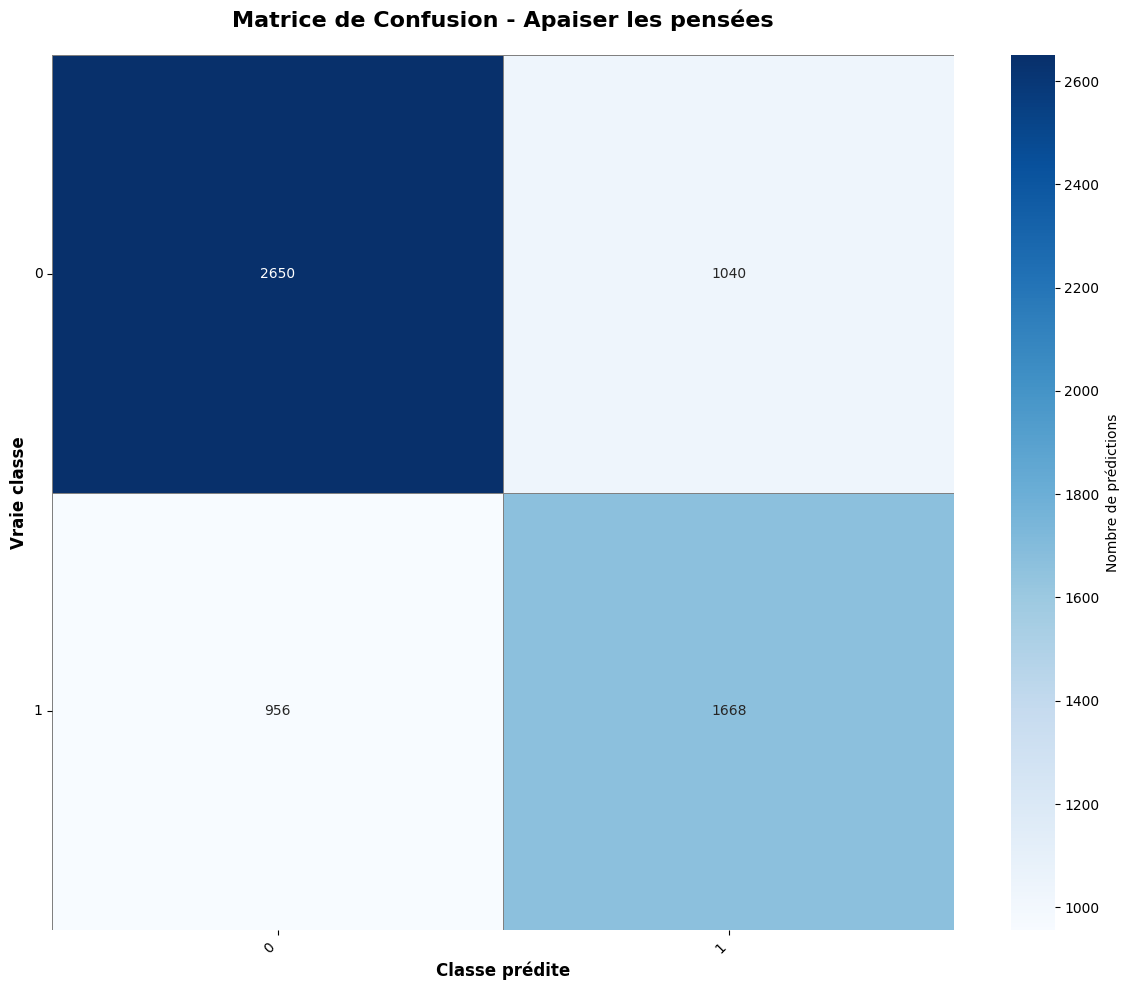

Comprendre l’origine du stress {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}
Entrainement fini
Validation
Score:  0.7572062084257206
Accuracy: 0.7572062084257206
ROC AUC: 0.8083257640698253
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      4287
           1       0.60      0.74      0.66      2027

    accuracy                           0.76      6314
   macro avg       0.73      0.75      0.74      6314
weighted avg       0.78      0.76      0.76      6314



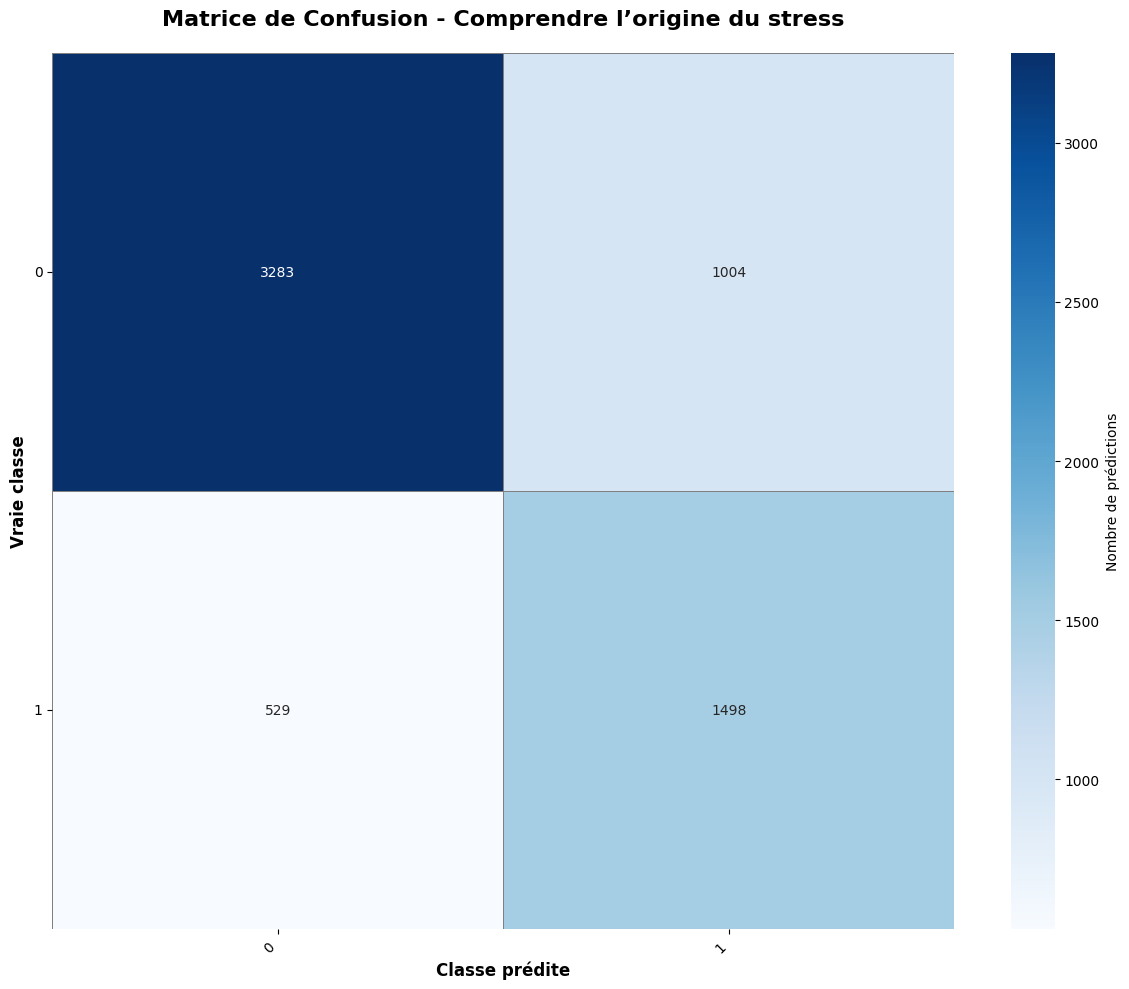

Mon Cogito {'model': RandomForestClassifier(max_depth=5, random_state=42), 'model__max_depth': 5, 'model__n_estimators': 200}
Entrainement fini
Importance des features
('MP_EVITEMENT_SOCRATE', np.float64(0.3422364343497068))
('MP_ALLER_VERS_SOCRATE', np.float64(0.2957801001949213))
('USER_OWNS_MASK', np.float64(0.13739301012182706))
('MP_PROCEDURE_SOCRATE', np.float64(0.07205718479164397))
('USER_OWNS_SUBSCRIPTION', np.float64(0.05375226829336349))
('MP_OPTION_SOCRATE', np.float64(0.04970161312098194))
('USER_APP_LANGUAGE', np.float64(0.03068714658722555))
('USER_USE_ANDROID', np.float64(0.012543468335728863))
('USER_USE_IOS', np.float64(0.005066755813473655))
('USER_AGE', np.float64(0.0007820183911275555))
('USER_GENDER', np.float64(0.0))
Validation
Score:  0.7553056699398163
Accuracy: 0.7553056699398163
ROC AUC: 0.7972619493820308
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      4331
           1       0.58      0.77      0.66   

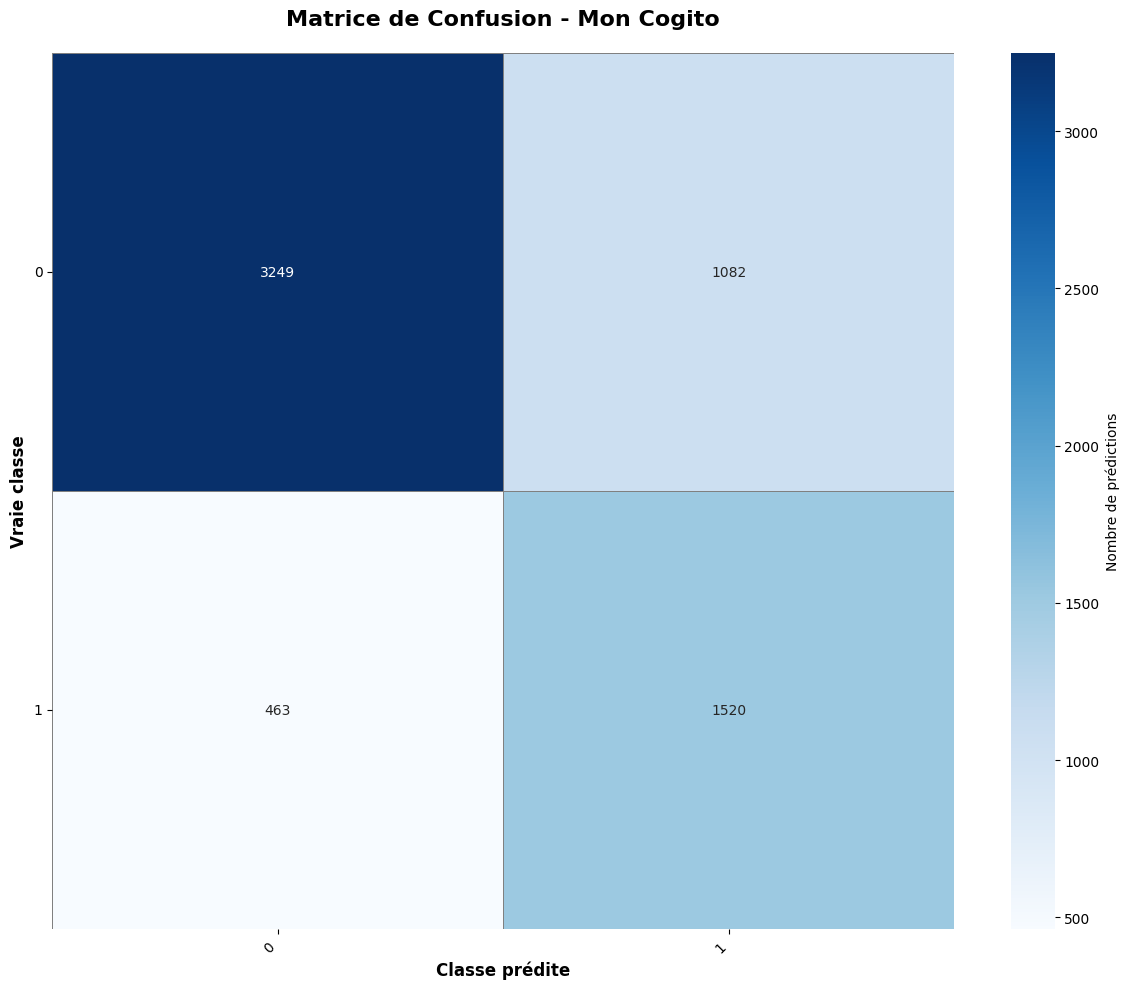

Stop grignotage {'model': GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200,
                           random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.6963889768767818
Accuracy: 0.6963889768767818
ROC AUC: 0.7050031862048124
              precision    recall  f1-score   support

           0       0.74      0.86      0.80      4358
           1       0.52      0.34      0.41      1956

    accuracy                           0.70      6314
   macro avg       0.63      0.60      0.60      6314
weighted avg       0.67      0.70      0.68      6314



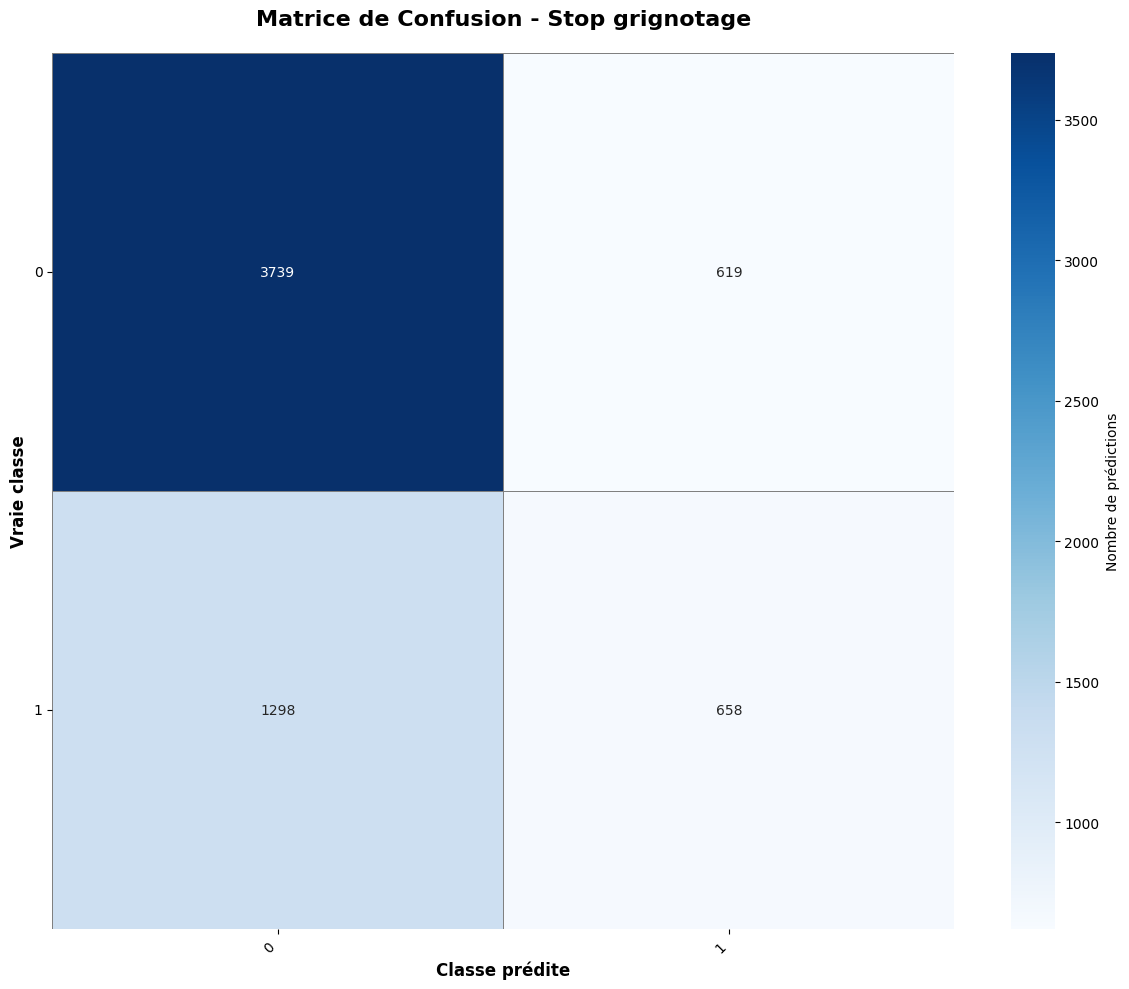

Douce nuit {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
Entrainement fini
Validation
Score:  0.7098511244852709
Accuracy: 0.7098511244852709
ROC AUC: 0.7656936108085978
              precision    recall  f1-score   support

           0       0.72      0.96      0.82      4433
           1       0.56      0.11      0.19      1881

    accuracy                           0.71      6314
   macro avg       0.64      0.54      0.51      6314
weighted avg       0.67      0.71      0.63      6314



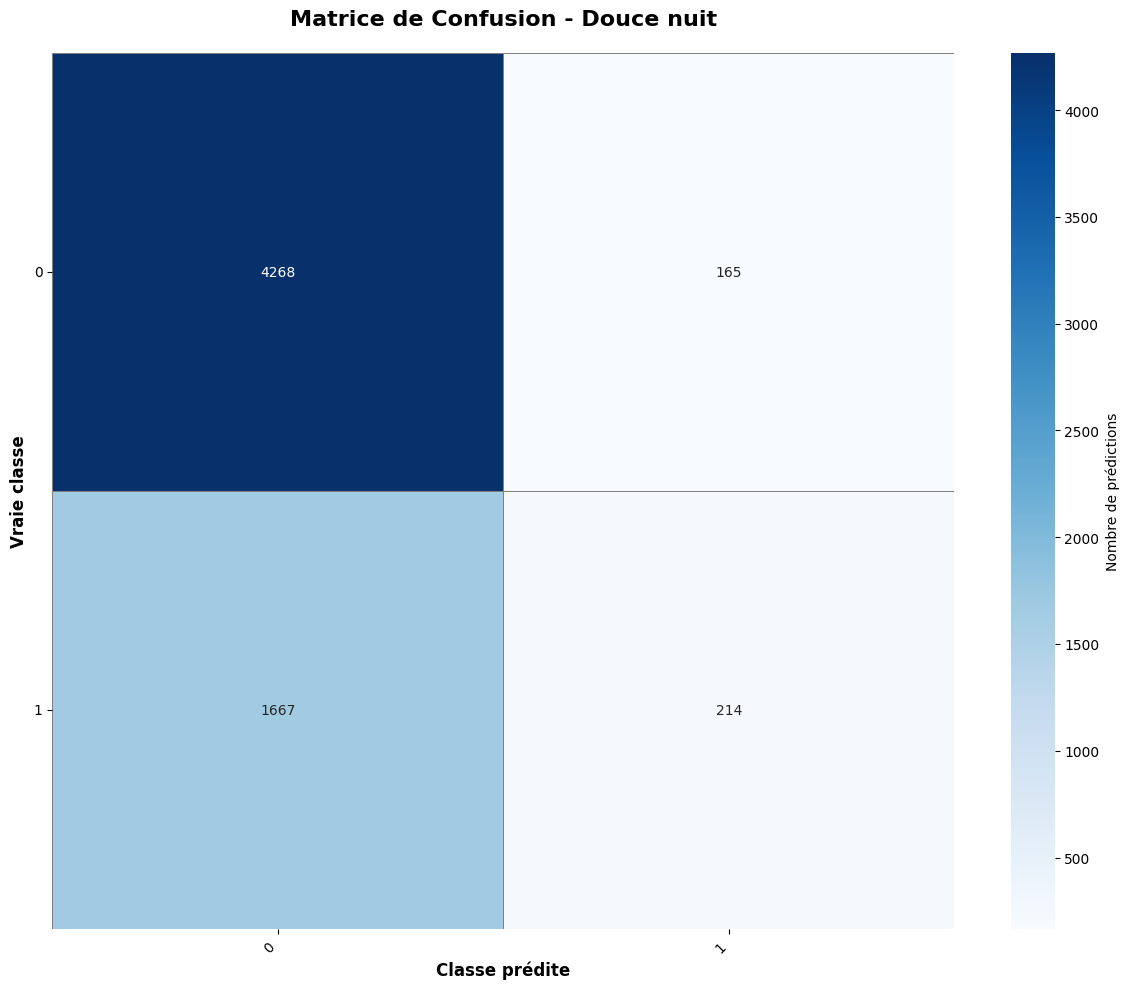

Bon voyage ! {'model': GradientBoostingClassifier(learning_rate=0.01, n_estimators=200,
                           random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
Entrainement fini
Validation
Score:  0.7812796959138423
Accuracy: 0.7812796959138423
ROC AUC: 0.8387952359627238
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      4466
           1       0.59      0.83      0.69      1848

    accuracy                           0.78      6314
   macro avg       0.75      0.80      0.76      6314
weighted avg       0.82      0.78      0.79      6314



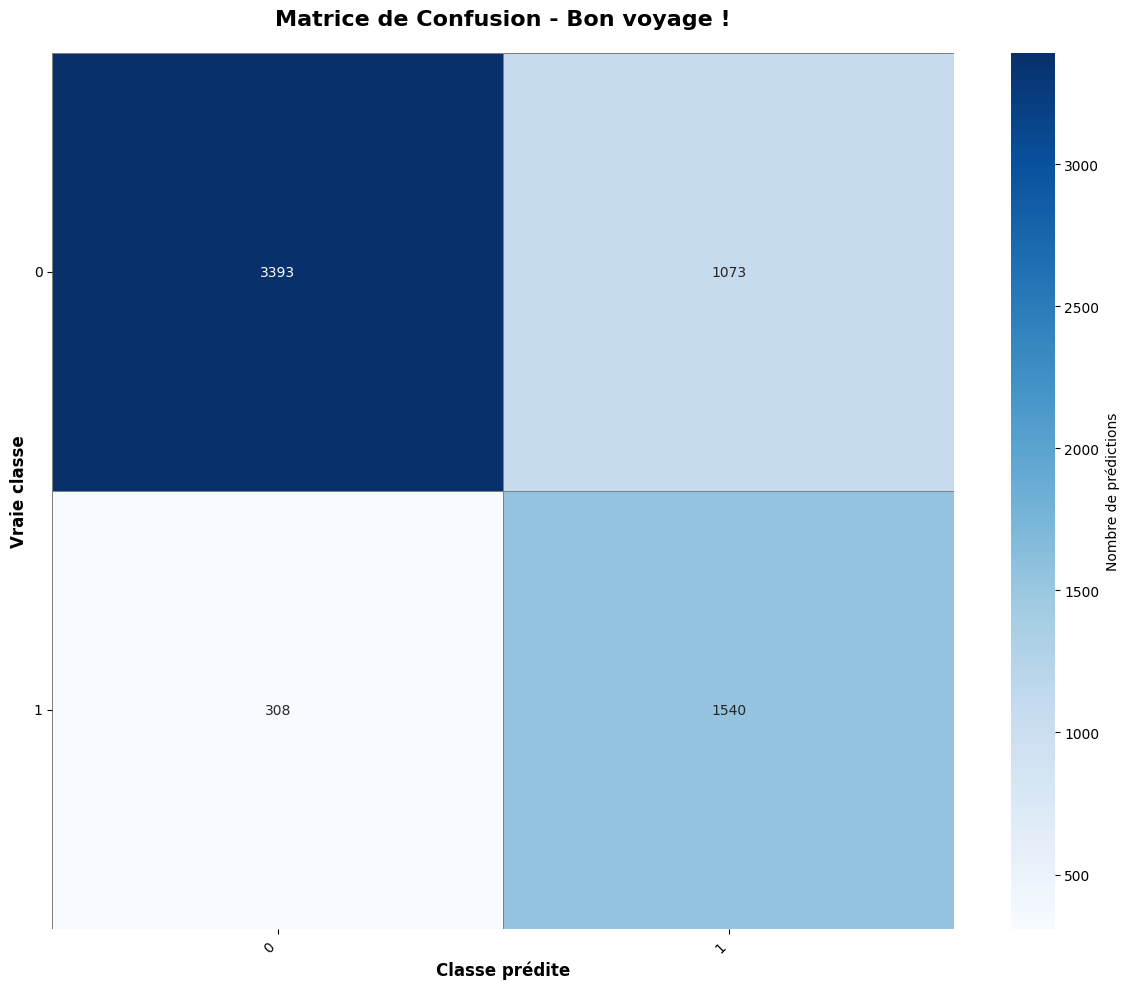

Phenix Santé {'model': GradientBoostingClassifier(learning_rate=0.01, n_estimators=200,
                           random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
Entrainement fini
Validation
Score:  0.8097877732024074
Accuracy: 0.8097877732024074
ROC AUC: 0.862389439115414
              precision    recall  f1-score   support

           0       0.93      0.79      0.86      4530
           1       0.62      0.86      0.72      1784

    accuracy                           0.81      6314
   macro avg       0.78      0.82      0.79      6314
weighted avg       0.84      0.81      0.82      6314



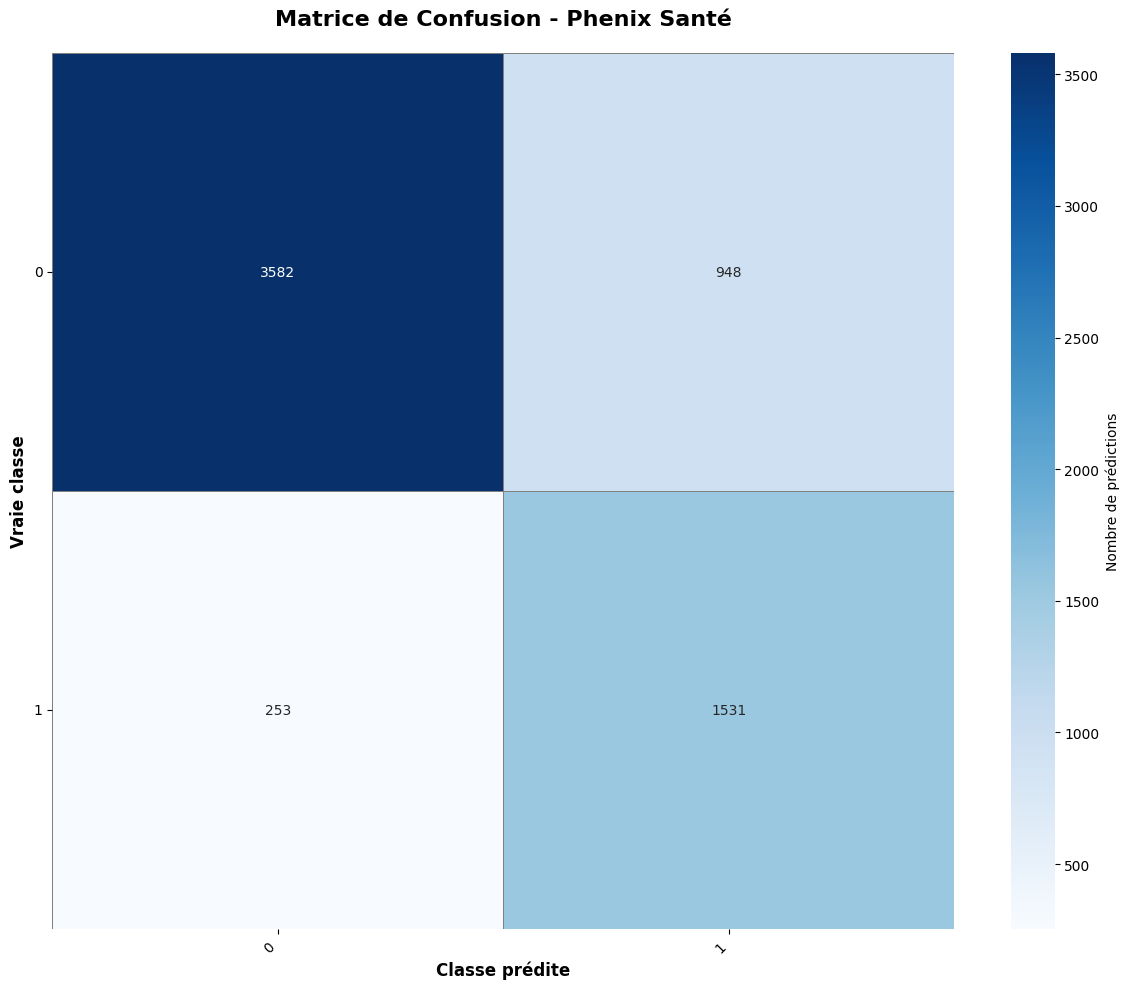

Qui dort, dîne? {'model': GradientBoostingClassifier(learning_rate=0.01, n_estimators=200,
                           random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.7420019005384859
Accuracy: 0.7420019005384859
ROC AUC: 0.7927541676011065
              precision    recall  f1-score   support

           0       0.80      0.85      0.83      4550
           1       0.55      0.46      0.50      1764

    accuracy                           0.74      6314
   macro avg       0.67      0.66      0.66      6314
weighted avg       0.73      0.74      0.73      6314



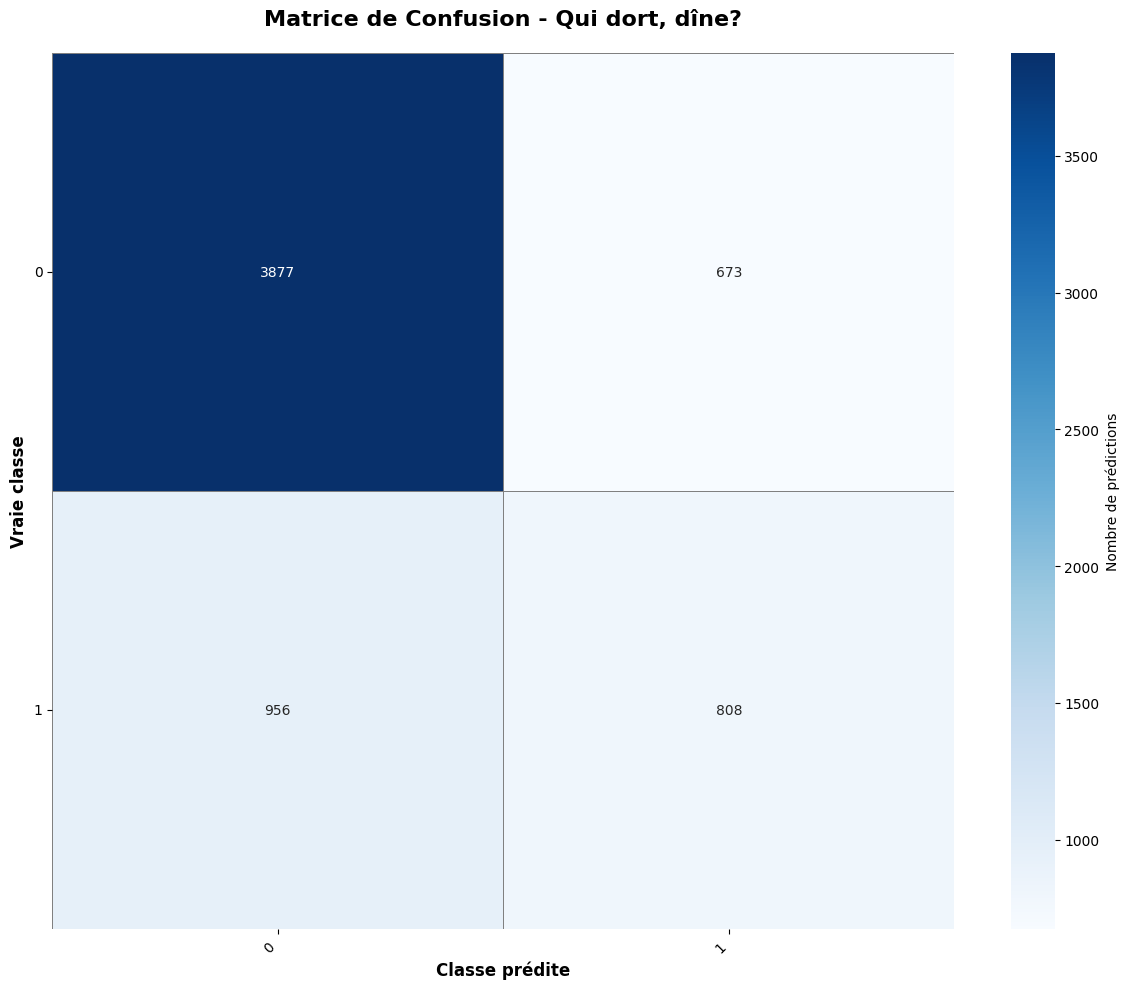

Mincir {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.7519797275894837
Accuracy: 0.7519797275894837
ROC AUC: 0.8124407767787494
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      4589
           1       0.54      0.58      0.56      1725

    accuracy                           0.75      6314
   macro avg       0.69      0.70      0.69      6314
weighted avg       0.76      0.75      0.75      6314



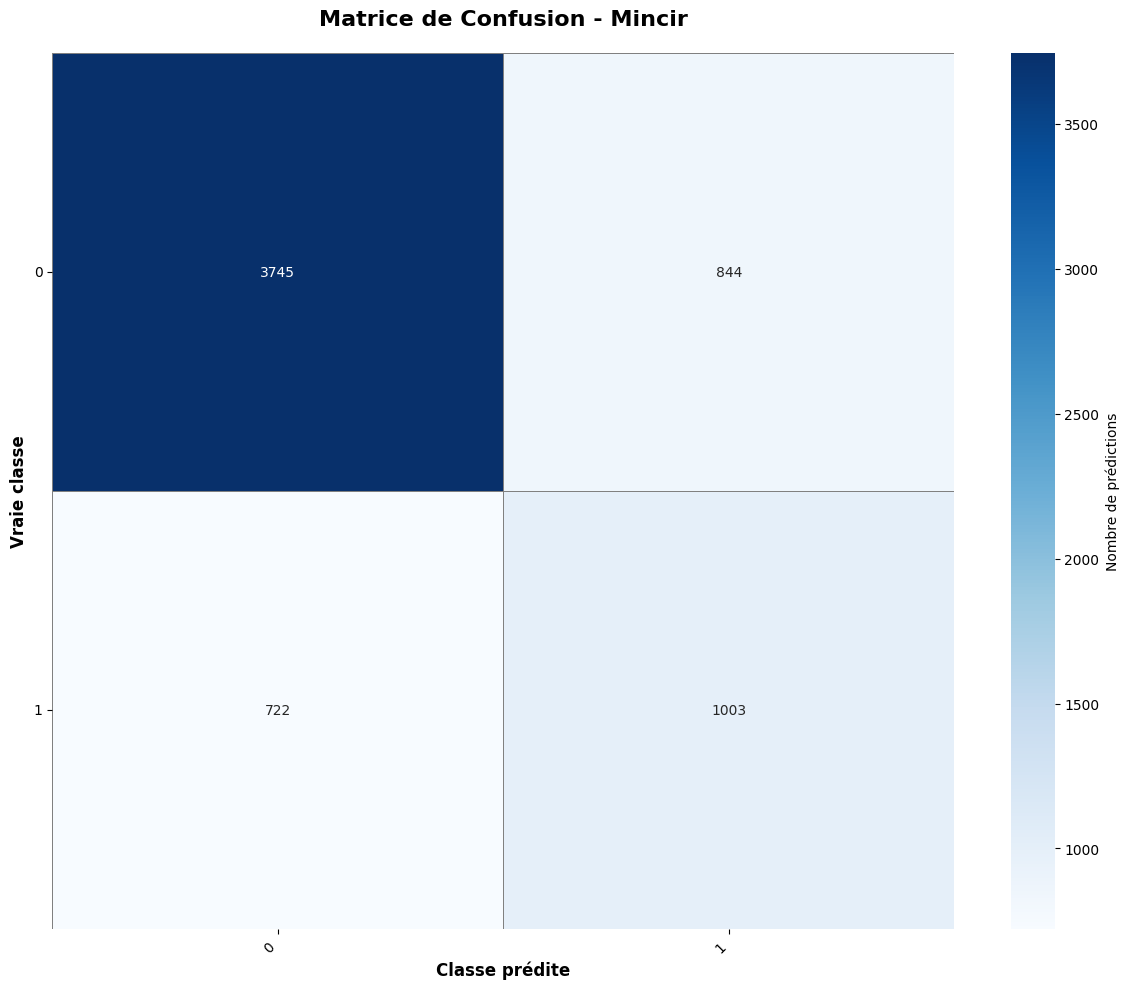

Mes déclencheurs {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}
Entrainement fini
Validation
Score:  0.7535635096610707
Accuracy: 0.7535635096610707
ROC AUC: 0.8069078178966513
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      4672
           1       0.55      0.27      0.36      1642

    accuracy                           0.75      6314
   macro avg       0.67      0.60      0.60      6314
weighted avg       0.72      0.75      0.72      6314



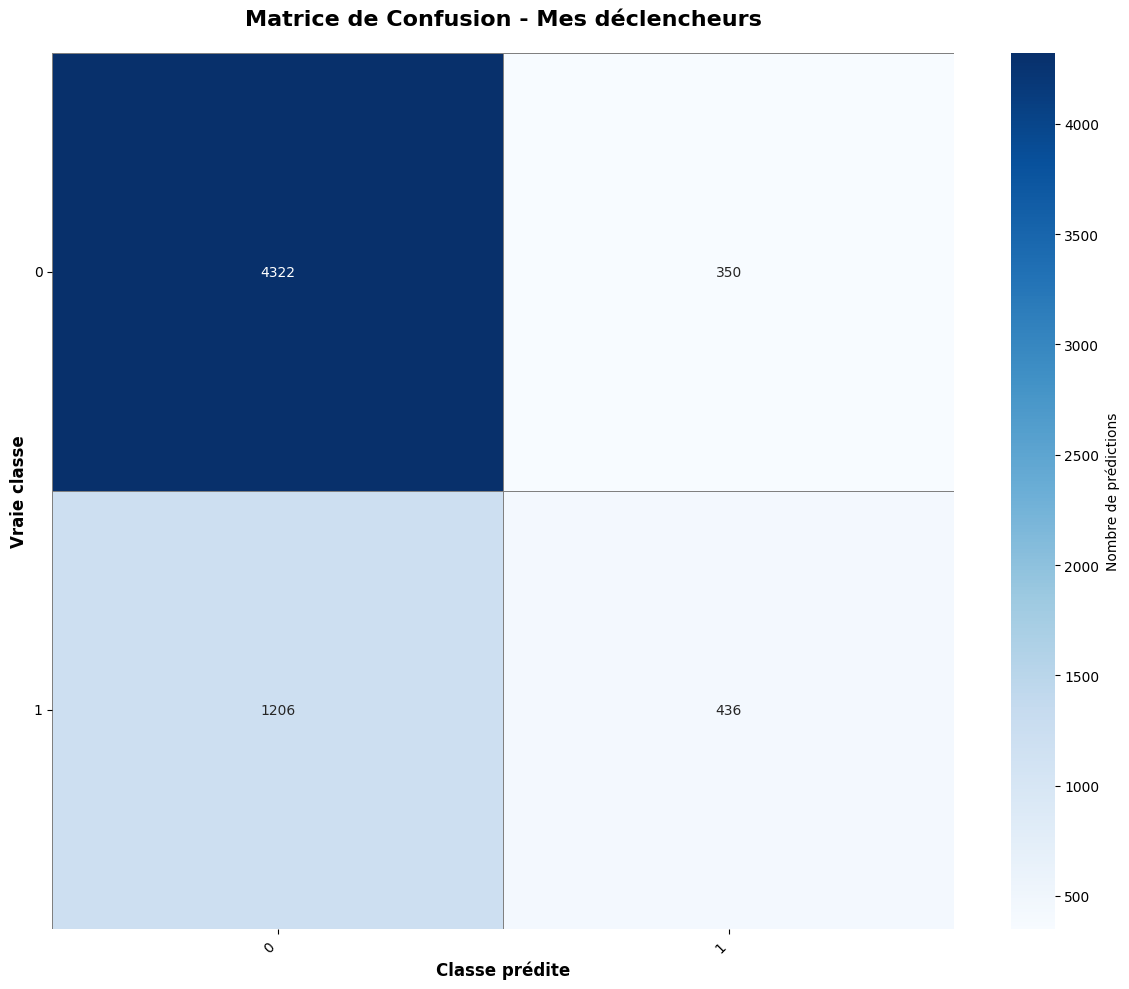

Liste des déclencheurs {'model': GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200,
                           random_state=42), 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.7432689261957555
Accuracy: 0.7432689261957555
ROC AUC: 0.7968953503773246
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      4692
           1       0.67      0.00      0.00      1622

    accuracy                           0.74      6314
   macro avg       0.70      0.50      0.43      6314
weighted avg       0.72      0.74      0.63      6314



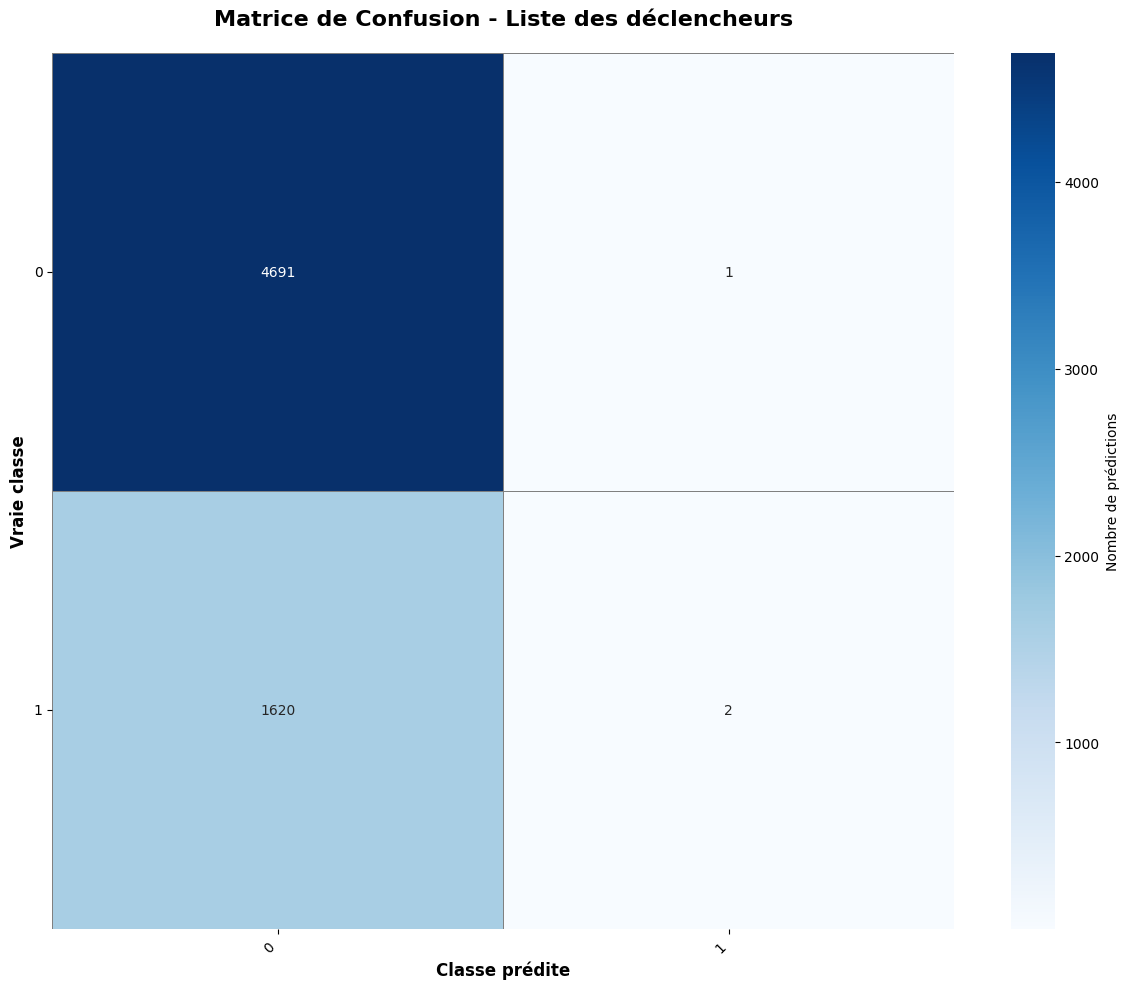

Nettoyer son esprit {'model': GradientBoostingClassifier(learning_rate=0.01, max_depth=5, random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.748178650617675
Accuracy: 0.748178650617675
ROC AUC: 0.6981111265556291
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      4731
           1       0.35      0.01      0.01      1583

    accuracy                           0.75      6314
   macro avg       0.55      0.50      0.43      6314
weighted avg       0.65      0.75      0.64      6314



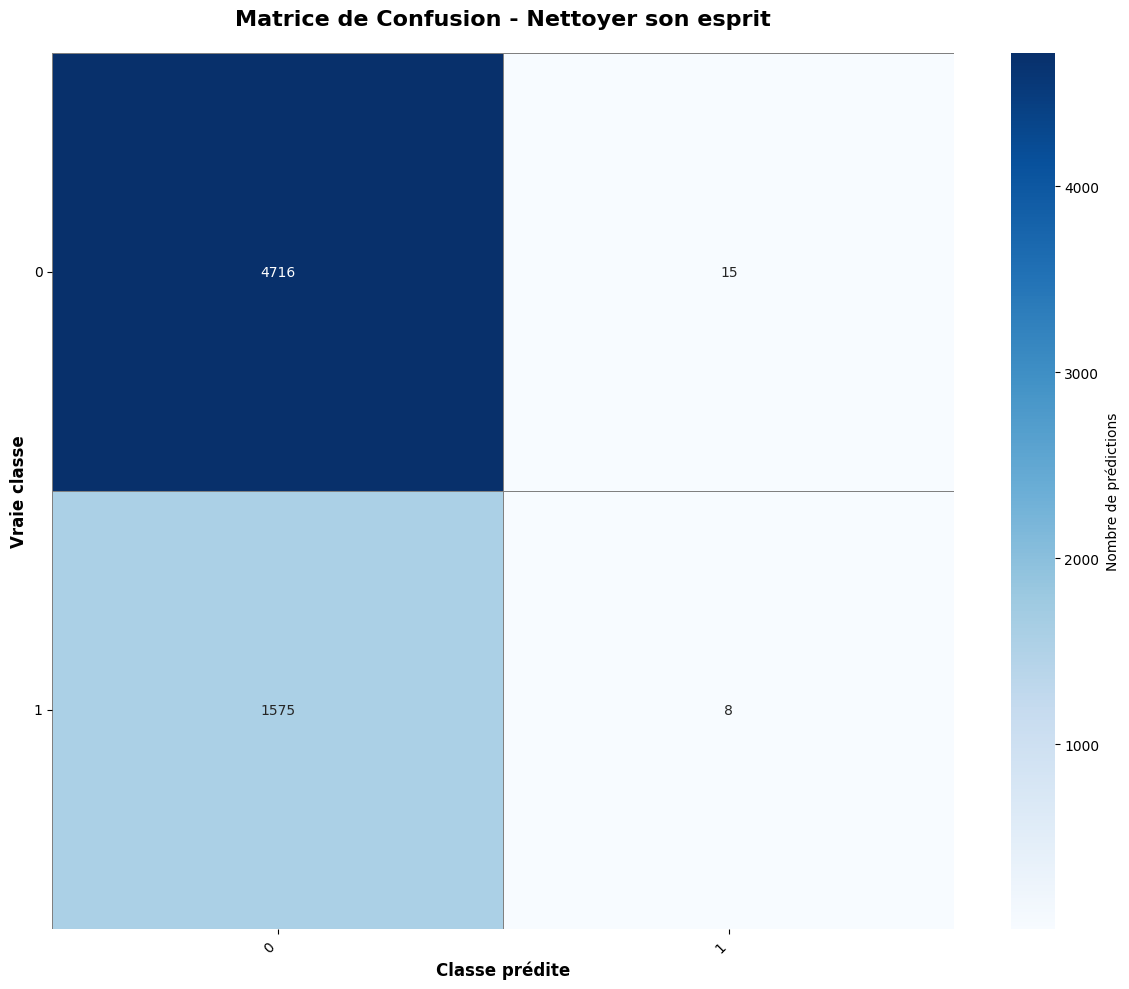

In [14]:
for content, params in best_params_for_content.items():
    print(content, params.best_params_)
    X_train = DATASETS[content]["X_train"]
    y_train = DATASETS[content]["y_train"]

    best_pipeline = pipeline.set_params(**params.best_params_)
    best_pipeline.fit(X_train, y_train)

    print("Entrainement fini")

    if isinstance(best_pipeline.steps[1][1], RandomForestClassifier):
        print("Importance des features")
        zip_features = zip(X_train.columns, best_pipeline.steps[1][1].feature_importances_)
        zip_features = sorted(zip_features, key=lambda x: x[1], reverse=True)
        for zf in zip_features:
            print(zf)

    print("Validation")
    X_test = DATASETS[content]["X_test"]

    y_test = DATASETS[content]["y_test"]
    score = best_pipeline.score(X_test, y_test)
    print("Score: ", score)

    # prédictions
    y_pred = best_pipeline.predict(X_test)

    # probabilités
    y_proba = best_pipeline.predict_proba(X_test)[:,1]

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("ROC AUC:", roc_auc_score(y_test, y_proba))

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test.values, y_pred)

    # Visualisation
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["0", "1"], yticklabels=["0", "1"],
                cbar_kws={'label': 'Nombre de prédictions'},
                linewidths=0.5, linecolor='gray')
    plt.title(f'Matrice de Confusion - {content}', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Vraie classe', fontsize=12, fontweight='bold')
    plt.xlabel('Classe prédite', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()